In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from smooth_POD_ROM.initial_conditions import rectangular_pulse, small_r_pulse
from smooth_POD_ROM.post_processing import get_sigma, richardson_lucy
from smooth_POD_ROM.reduced_order_model import make_training_data, get_data_rw, L2_error_rw, L1_error_rw,target_function, snapshots_rowwise, optimize_sROM

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
single_column_figure = (single_column_in, single_column_in/1.618)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40
#pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
#pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
markevery = 100

In [3]:
def initial_condition(x, mu):
    return rectangular_pulse(x, mu, w=0.02 + 1e-6)

In [4]:
n_x = 500
x = np.linspace(0, 1, n_x, endpoint=False)

n_test =  50
mu_test = np.linspace(0, 1, n_test)[:, None]

case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "mu_test": mu_test,
    "g": initial_condition, # initial_condition, small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "mode": "wrap",
    "sigma": 0.06,

    "c": 2,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}

In [5]:
N_max = 150 # max rank
n_trials = 5
_sima_ = 0.016
_sima2_ = 0.032
c = 2

case["sigma"] = _sima_
X_test, X_test_s1 = get_data_rw(mu_test, **case)
case["sigma"] = _sima2_
X_test, X_test_s2 = get_data_rw(mu_test, **case)

10.0 9.999999999999998 10.000000000000002
10.0 10.0 9.999999999999998


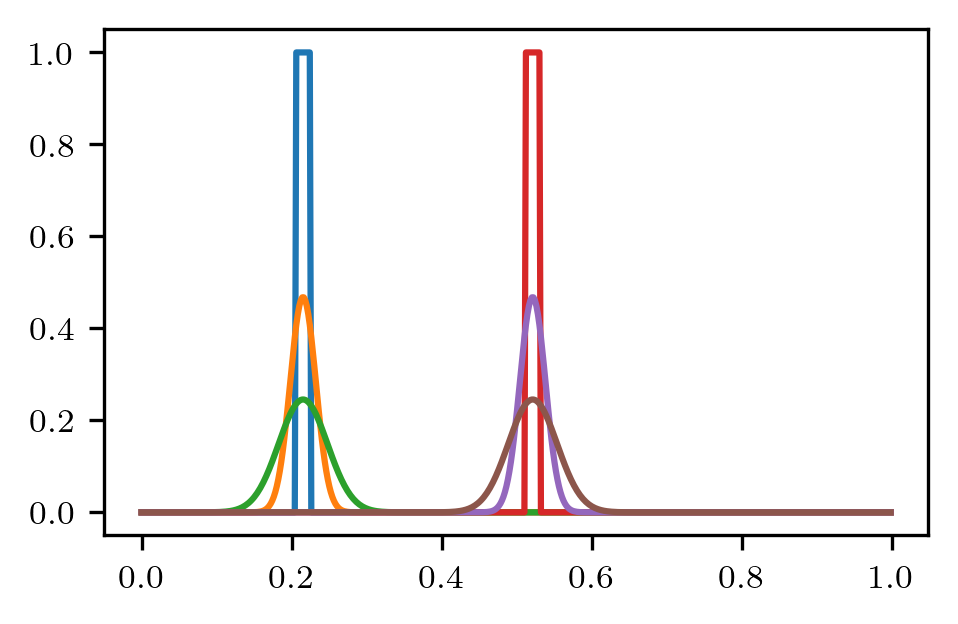

In [6]:

for i in [10, 25]:
    print(np.sum(X_test[i]), np.sum(X_test_s1[i]), np.sum(X_test_s2[i]))
    plt.plot(x, X_test[i])
    plt.plot(x, X_test_s1[i])
    plt.plot(x, X_test_s2[i])
plt.show()

In [7]:


NN = np.arange(1, N_max, 1)
e_conventional = np.zeros((len(NN), n_trials))
e_smooth1 = np.zeros((len(NN), n_trials))-1
e_smooth2 = np.zeros((len(NN), n_trials))-1
e_desmoothed1 = np.zeros((len(NN), n_trials))-1
e_desmoothed2 = np.zeros((len(NN), n_trials))-1

for i, n in enumerate(NN):
    for trial in range(n_trials):
        mu_train = np.random.rand(n)[:, None]
        case["sigma"] = _sima_
        basis1, basis2 = get_data_rw(mu_train, **case)
        case["sigma"] = _sima2_
        _, basis3 = get_data_rw(mu_train, **case)

        
        coefficients1, _, _, _ = np.linalg.lstsq(basis1.T, X_test.T, rcond=None)  # solves a@x=b given a and b
        coefficients2, _, _, _ = np.linalg.lstsq(basis2.T, X_test_s1.T, rcond=None)  # solves a@x=b given a and b
        coefficients3, _, _, _ = np.linalg.lstsq(basis3.T, X_test_s2.T, rcond=None)  # solves a@x=b given a and b
        approximations1 = (basis1.T @ coefficients1).T  # same as X_test_ROM?
        approximations2 = (basis2.T @ coefficients2).T  # same as X_test_sROM?
        approximations3 = (basis3.T @ coefficients3).T  # same as X_test_sROM?


        approximations2DS = np.empty_like(approximations2)
        approximations3DS = np.empty_like(approximations3)
        for j in range(len(mu_test)):
            sgm_est = get_sigma(_sima_, mu_test[j][None, ...], mu_train, c=c)
            approximations2DS[j] = richardson_lucy(x, approximations2[j], sgm_est, num_iter=200, monitor_convergence=False)[0].reshape(approximations2DS[j].shape)
            sgm_est = get_sigma(_sima2_, mu_test[j][None, ...], mu_train, c=c)
            approximations3DS[j] = richardson_lucy(x, approximations3[j], sgm_est, num_iter=200, monitor_convergence=False)[0].reshape(approximations3DS[j].shape)
            
        e_conventional[i, trial] = np.mean(L2_error_rw(approximations1, X_test))
        e_smooth1[i, trial] = np.mean(L2_error_rw(approximations2, X_test))
        e_smooth2[i, trial] = np.mean(L2_error_rw(approximations3, X_test))
        e_desmoothed1[i, trial] = np.mean(L2_error_rw(approximations2DS, X_test))
        e_desmoothed2[i, trial] = np.mean(L2_error_rw(approximations3DS, X_test))

    print(n, np.median(e_conventional[i, :]), np.median(e_desmoothed1[i, :]),  np.median(e_desmoothed2[i, :]))

np.save(pth+"/NN.npy", NN)
np.save(pth+"/e_conventional.npy", e_conventional)
np.save(pth+"/e_smooth1.npy", e_smooth1)
np.save(pth+"/e_smooth2.npy", e_smooth2)
np.save(pth+"/e_desmoothed1.npy", e_desmoothed1)
np.save(pth+"/e_desmoothed2.npy", e_desmoothed2)

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


1 0.14050894409495918 0.14206084367202684 0.14283146244788836
2 0.13916311070416768 0.1426458289076094 0.14554102366948657
3 0.13834711676498326 0.14318167237603235 0.14002418136098874
4 0.13733472264373517 0.1371460072296481 0.13376215181578346
5 0.13667389200082214 0.13848662996364736 0.13770641798729336
6 0.13565241838086572 0.14305816574744948 0.12899755097801546
7 0.13420913415099275 0.13754803745135885 0.13042585970316167
8 0.1329637658149359 0.12975473372643592 0.12043263404811301
9 0.13071650669040108 0.12343180116414447 0.1129202982861217
10 0.12940065973008927 0.12947225712954424 0.10877409767770738
11 0.12917038283268628 0.1195384841260329 0.10159870696216763
12 0.12453691436110492 0.12245801803413155 0.09681917283936409
13 0.12470642603428118 0.11610099525108604 0.09861402158744179
14 0.1256660310003951 0.11870412688813117 0.08876667876243025
15 0.12472423006531247 0.1059529275755006 0.08123372481112033
16 0.12281240724576259 0.1059687521727618 0.07949434134811054
17 0.1216

In [8]:
NN = np.load(pth+"/NN.npy")
e_conventional = np.load(pth+"/e_conventional.npy")
e_smooth1 = np.load(pth+"/e_smooth1.npy")
e_smooth2 = np.load(pth+"/e_smooth2.npy")
e_desmoothed1 = np.load(pth+"/e_desmoothed1.npy")
e_desmoothed2 = np.load(pth+"/e_desmoothed2.npy")

In [9]:
yticks = [*np.linspace(0.0001, 0.001, 10), *np.linspace(0.001, 0.01, 10), *np.linspace(0.01, 0.1, 10)]
[str(t) for t in yticks]

['0.0001',
 '0.00019999999999999998',
 '0.0003',
 '0.00039999999999999996',
 '0.0005',
 '0.0006000000000000001',
 '0.0007',
 '0.0007999999999999999',
 '0.0009',
 '0.001',
 '0.001',
 '0.002',
 '0.003',
 '0.004',
 '0.005',
 '0.006',
 '0.007',
 '0.008',
 '0.009000000000000001',
 '0.01',
 '0.01',
 '0.020000000000000004',
 '0.030000000000000006',
 '0.04000000000000001',
 '0.05000000000000001',
 '0.06000000000000001',
 '0.07',
 '0.08',
 '0.09000000000000001',
 '0.1']

0.09443427097105038
0.11762821153561978
0.009607983457227383
0.03121675143408249


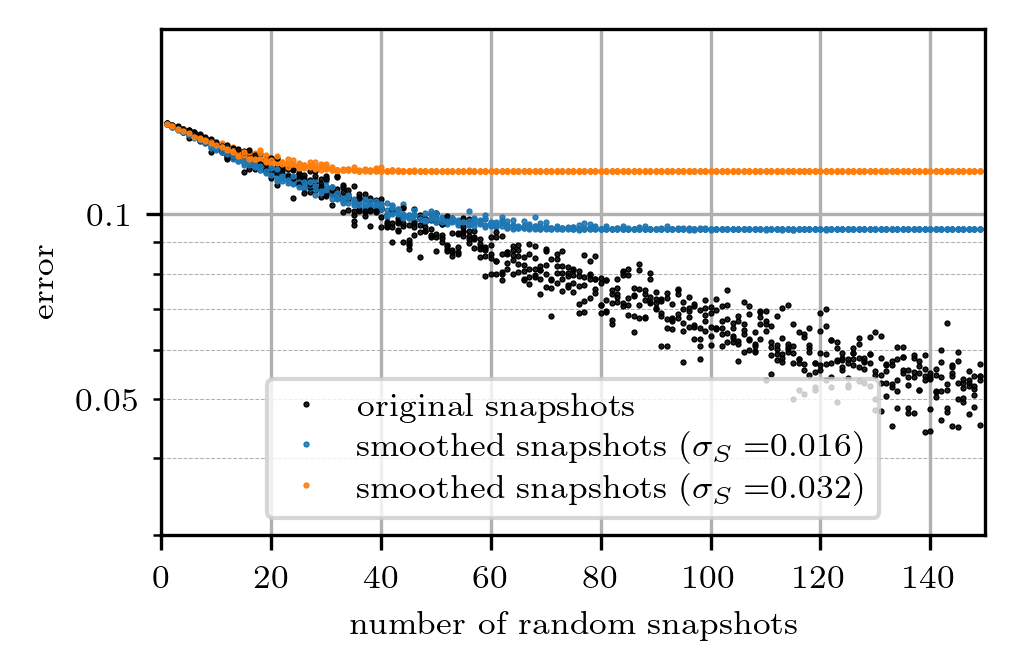

0.09443427097105038
0.11762821153561978
0.009607983457227383
0.03121675143408249


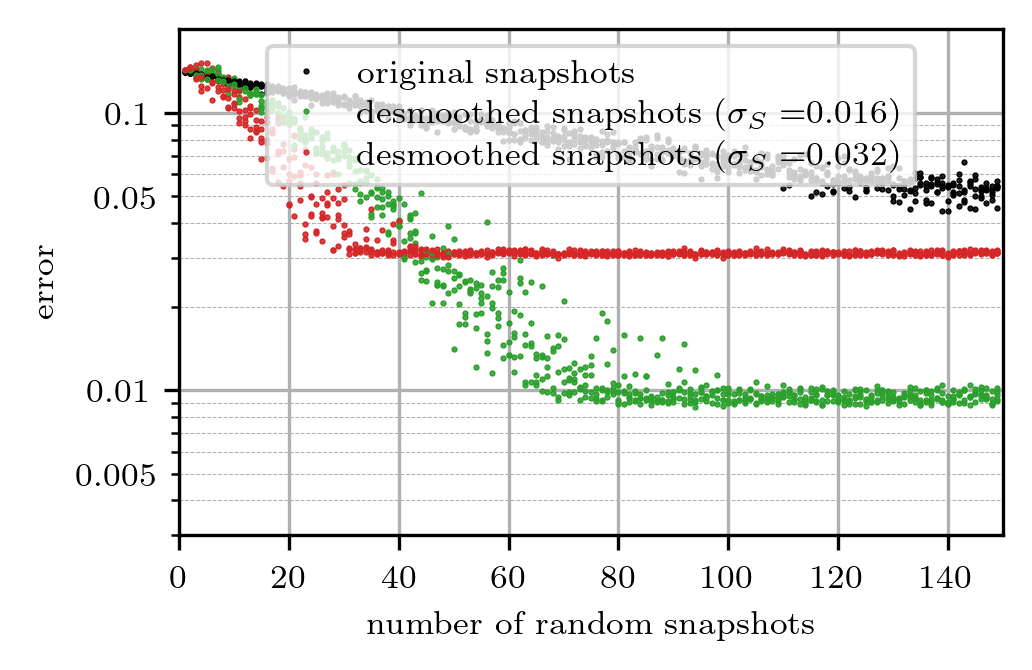

In [10]:
for name in ["random_smooth_data_fixed_sigma", "random_smooth_data_desmoothed_fixed_sigma"]:

    fig, ax = plt.subplots()
    ax.plot(0, 1, "k.", ms=1, label="original snapshots")
    if name == "random_smooth_data_fixed_sigma":
        ax.plot(0, 1, "C0.", ms=1, label=r"smoothed snapshots ($\sigma_S=${:.3f})".format(_sima_))
        ax.plot(0, 1, "C1.", ms=1, label=r"smoothed snapshots ($\sigma_S=${:.3f})".format(_sima2_))
        ymin=3e-2
    if name == "random_smooth_data_desmoothed_fixed_sigma":
        ax.plot(0, 1, "C2.", ms=1, label=r"desmoothed snapshots ($\sigma_S=${:.3f})".format(_sima_))
        ax.plot(0, 1, "C3.", ms=1, label=r"desmoothed snapshots ($\sigma_S=${:.3f})".format(_sima2_))
        ymin=3e-3
    
    for trial in range(n_trials):
        ax.plot(NN, e_conventional[:, trial], "k.", ms=1)
        if name == "random_smooth_data_fixed_sigma":
            ax.plot(NN, e_smooth1[:, trial], "C0.", ms=1)
            ax.plot(NN, e_smooth2[:, trial], "C1.", ms=1)
            ll = NN>80
        if name == "random_smooth_data_desmoothed_fixed_sigma":
            ax.plot(NN, e_desmoothed1[:, trial], "C2.", ms=1)
            ax.plot(NN, e_desmoothed2[:, trial], "C3.", ms=1)
    print(np.mean(e_smooth1[ll, :]))
    print(np.mean(e_smooth2[ll, :]))
    print(np.mean(e_desmoothed1[ll, :]))
    print(np.mean(e_desmoothed2[ll, :]))
    
    ax.grid()
    #ax.set_xscale('log')
    ax.set_yscale('log')
    #ax.set_yticks([*np.linspace(.01, .1, 10, endpoint=True), *np.linspace(.1, 1, 10, endpoint=True)], minor=True)
    #ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    #ax.grid(True, which='both')

    
    # yticks = [*np.linspace(0.0001, 0.001, 10), *np.linspace(0.001, 0.01, 10), *np.linspace(0.01, 0.1, 10)]
    # ax.set_yticks(yticks, minor=True)
    # ax.set_yticks([0.001, 0.01, 0.1], minor=False)
    # ax.set_yticklabels(30*[""], minor=True)
    # ax.set_yticklabels(["0.001", "0.01", "0.1"], minor=False)
    from matplotlib.ticker import FixedLocator, FuncFormatter
    major = np.array([1e-3, 1e-2, 1e-1])
    ax.yaxis.set_major_locator(FixedLocator(major))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:g}"))
    minor = np.r_[
        np.linspace(1e-4, 1e-3, 10),
        np.linspace(1e-3, 1e-2, 10),
        np.linspace(1e-2, 1e-1, 10),
    ]
    minor = np.unique(minor)
    minor = minor[~np.isin(minor, major)]
    ax.yaxis.set_minor_locator(FixedLocator(minor))
    wanted_minor = {
        5e-3: "0.005",
        5e-2: "0.05",
        5e-1: "0.5",
    }
    def minor_fmt(y, pos):
        # robust to floating-point representation
        for v, s in wanted_minor.items():
            if np.isclose(y, v, rtol=0, atol=max(1e-15, v*1e-12)):
                return s
        return ""
    ax.yaxis.set_minor_formatter(FuncFormatter(minor_fmt))

    
    ax.set_ylim([ymin, 0.2])
    ax.set_xlim([0, 150])
    #ax.set_xlim([10, 100])
    #ax.set_xticklabels(["", "10", "20", "30", "", "50", "", "", "", "", "100"], minor=True)
    ax.set_xlabel("number of random snapshots")
    ax.set_ylabel("error")
    if name == "random_smooth_data_fixed_sigma":
        plt.legend(loc='lower center')
    if name == "random_smooth_data_desmoothed_fixed_sigma":
        plt.legend(loc='upper center')
        
    plt.savefig(pth+name+".pdf", bbox_inches='tight') # random_smooth_data_fixed_sigma, random_smooth_data_desmoothed_fixed_sigma
    plt.show()


# ROM

In [11]:
n_x = 5000
x = np.linspace(0, 1, n_x, endpoint=False)

n_test =  100
#mu_test = np.linspace(0, 1, n_test)[:, None]

def narrow(x, mu):
    return rectangular_pulse(x, mu, w=0.02  + 1e-6)

case["n_x"] = n_x
case["shape"] = (n_x,)
case["x"] = x
case["num_iter"] = 100
case["sROM_only"] = False
case["g"] = narrow

In [12]:
X = snapshots_rowwise(case["g"], x, mu=np.linspace(0, 1, n_x, endpoint=False))
U, S, VT = np.linalg.svd(X.T, full_matrices=False)
a, b = X.shape

delta_n = (np.cumsum(S[::-1]**2)[::-1]/a/b)**.5
dN = delta_n


In [13]:
sig = [0.0025, 0.01]
sig = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])
#sig = np.array([0.032, 0.008])
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]
NN_ROM = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])

In [14]:
norm = L2_error_rw
case["norm"] = L2_error_rw

3
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.06400000, 2.00000000, 0.17435411, 0.13848296, 0.15072730, -13.5510
0.5474019744399119 0.5958019829666289
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.03200000, 2.00000000, 0.17435411, 0.14166065, 0.16816867, -3.5476
0.7919071251885956 0.940091426448233
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.01600000, 2.00000000, 0.17435411, 0.14812931, 0.18146729, 4.0797
1.1710649994221551 1.4346248870051945
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.00800000, 2.00000000, 0.17435411, 0.15759352, 0.18617810, 6.7816
1.7619490841166197 2.081534397649963
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.00400000, 2.00000000, 0.17435411, 0.16577678, 0.18

C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\1031714048.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


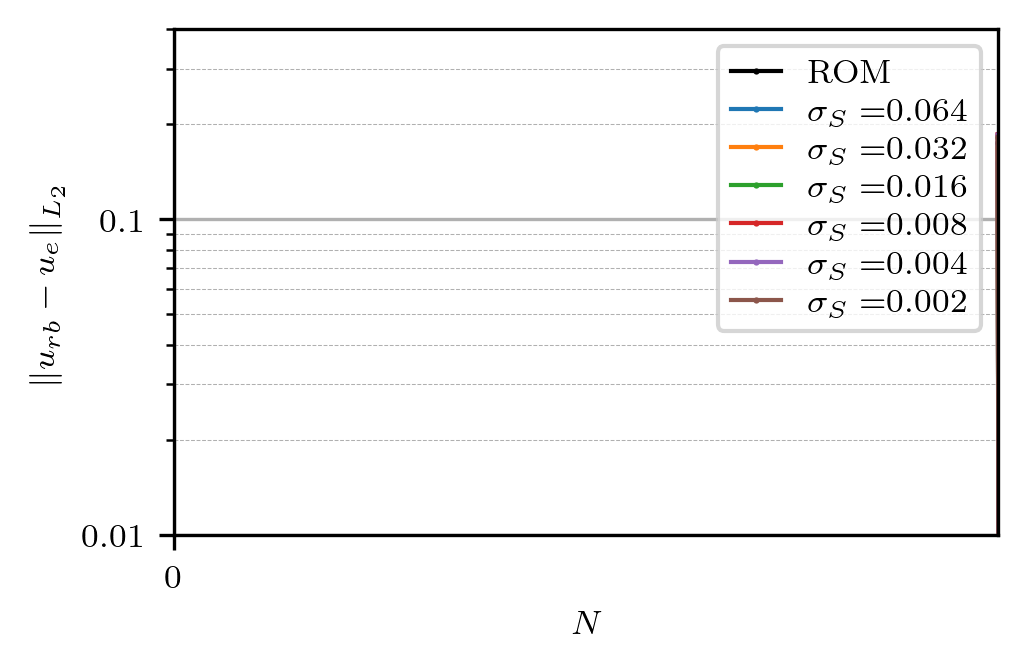

5


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.06400000, 2.00000000, 0.16973798, 0.13566385, 0.12731788, -24.9915
0.5362584521812458 0.5032681284893928
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.03200000, 2.00000000, 0.16973798, 0.13750992, 0.16307486, -3.9255
0.7687038340972816 0.9116161634211499
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.01600000, 2.00000000, 0.16973798, 0.14343086, 0.17708371, 4.3277
1.133920512584839 1.3999696583986034
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.00800000, 2.00000000, 0.16973798, 0.15266763, 0.18180789, 7.1109
1.7068759455329532 2.032674019465376
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.00400000, 2.00000000, 0.16973798, 0.16082508, 0.1810

C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\1031714048.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


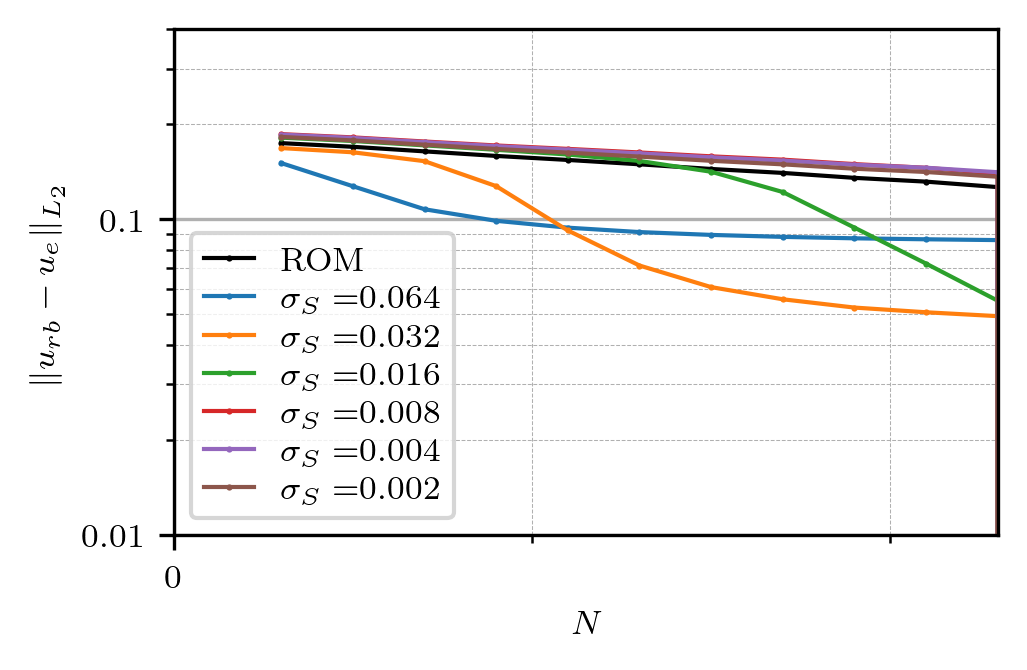

25


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.06400000, 2.00000000, 0.12282602, 0.13056142, 0.08547434, -30.4102
0.5160893315550122 0.3378670091066436
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.03200000, 2.00000000, 0.12282602, 0.12067327, 0.04827280, -60.6982
0.6745840819459217 0.26985314802232835
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.01600000, 2.00000000, 0.12282602, 0.10973927, 0.04592494, -62.6098
0.8675651388119797 0.363068554475131
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.00800000, 2.00000000, 0.12282602, 0.10757440, 0.13405222, 9.1399
1.202718408151334 1.4987493289583451
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.00400000, 2.00000000, 0.12282602, 0.1125564

C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\1031714048.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


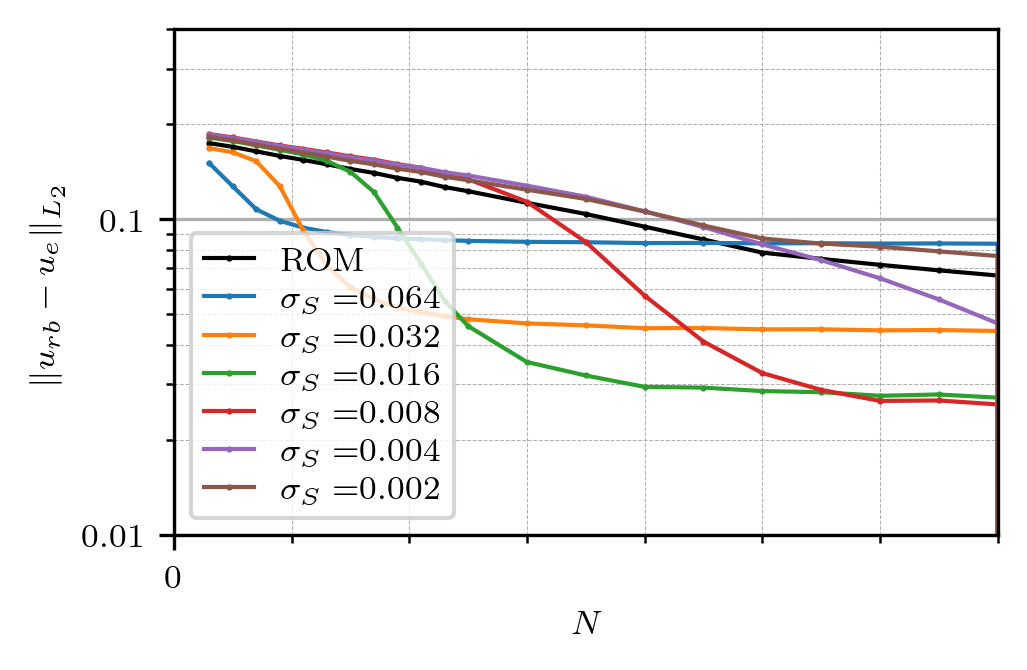

80


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.06400000, 2.00000000, 0.06203397, 0.12973743, 0.08366280, 34.8661
0.5128322078386334 0.3307062544524329
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.03200000, 2.00000000, 0.06203397, 0.11782056, 0.04419922, -28.7500
0.658636961706417 0.2470811700753573
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.01600000, 2.00000000, 0.06203397, 0.09645851, 0.02702330, -56.4379
0.76257145172639 0.2136379839656866
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.00800000, 2.00000000, 0.06203397, 0.07097108, 0.02643757, -57.3821
0.7934807421758266 0.29558102037282
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.00400000, 2.00000000, 0.06203397, 0.05726956, 

C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\1031714048.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


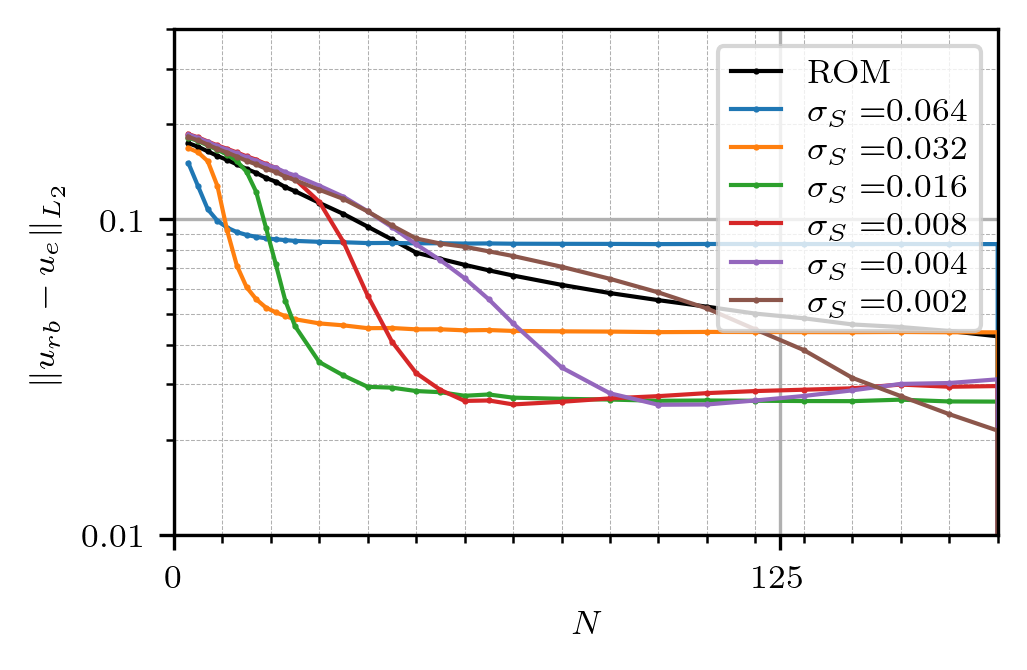

180


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.06400000, 2.00000000, 0.04070458, 0.12966595, 0.08349720, 105.1298
0.5125496540002648 0.3300516809498582
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.03200000, 2.00000000, 0.04070458, 0.11754344, 0.04386947, 7.7753
0.6570878119028939 0.24523781027289035
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.01600000, 2.00000000, 0.04070458, 0.09479360, 0.02647534, -34.9573
0.7494092188857442 0.2093059184194118
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.00800000, 2.00000000, 0.04070458, 0.06494474, 0.02982121, -26.7374
0.7261042159867269 0.33341129068271796
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.00400000, 2.00000000, 0.04070458, 0

C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\1031714048.py:45: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


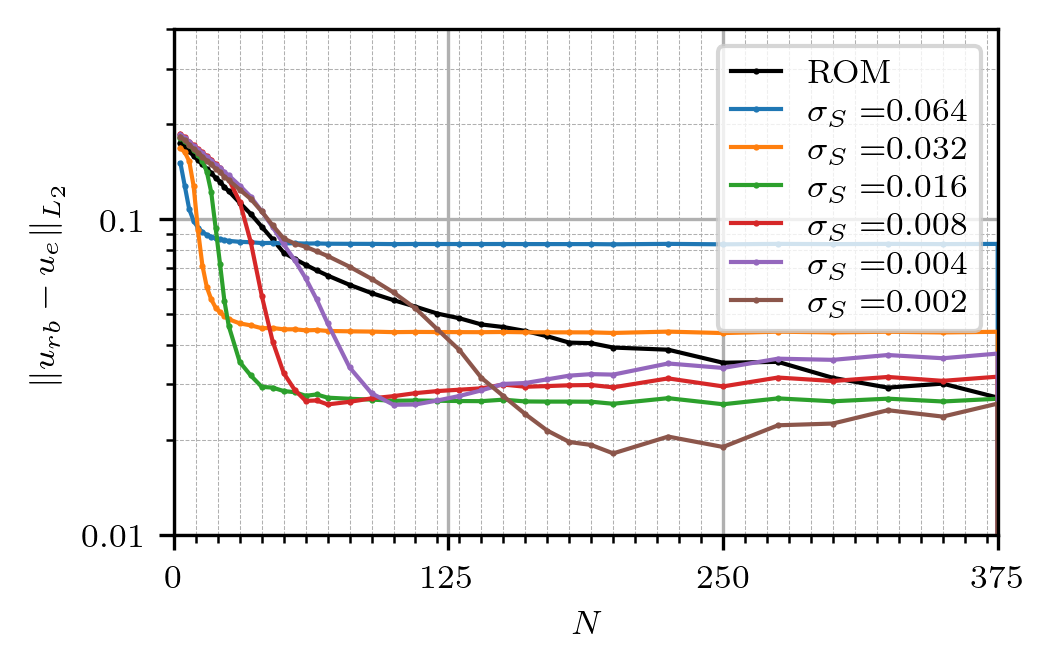

400


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.06400000, 2.00000000, 0.02760739, 0.12970064, 0.08347653, 202.3702
0.5126868131848626 0.32996995995233724
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.03200000, 2.00000000, 0.02760739, 0.11752759, 0.04382978, 58.7610
0.6569992111088121 0.24501589502910864
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.01600000, 2.00000000, 0.02760739, 0.09448110, 0.02646588, -4.1348
0.7469386416561508 0.2092311207896347
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.00800000, 2.00000000, 0.02760739, 0.06372034, 0.03083086, 11.6761
0.7124150073721142 0.3446995163111803
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.00400000, 2.00000000, 0.02760739, 0.

In [15]:
#NN = np.array([3, *np.arange(10, 200, 20), *np.arange(200, 525, 25)])
#NN = np.array([500])  # np.array([100, 150, 250, 350, 500])
#NN = np.array([3, 50, 100, 250, 500])
#NN = np.array([*np.arange(10, 30, 2), 50, 100, 200, 300, 400, 500])
dN_ROM = np.zeros(len(NN_ROM))
dN_ROMi = np.zeros(len(NN_ROM))



dN_sig_sROM = np.zeros((len(NN_ROM), len(sig)))
dN_sig_dsROM = np.zeros((len(NN_ROM), len(sig)))
for i, rank in enumerate(NN_ROM):
    n_train = rank
    print(rank)
    case["rank"] = rank
    case["n_train"] = n_train
    

    # case["mu_test"] = mu_test.copy()
    # in_range = mu_test[:, 0] < 1-1/rank
    # case["mu_test"] = case["mu_test"][in_range, :]
    s = rank//2
    mu_test = np.linspace(s/rank, (s+1)/rank, n_test, endpoint=False)[:, None]
    case["mu_test"] = mu_test
    
    basis = U[:, :rank]
    X_test, _ = get_data_rw(mu_test, **case)
    X_test_ROMi = (basis @ (basis.T @ X_test.T)).T
    e_ROMi = norm(X_test_ROMi, X_test)
    mean_ROMi = np.mean(e_ROMi)
    dN_ROMi[i] = mean_ROMi


    for j in range(len(sig)):
        case["sigma"] = sig[j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig_sROM[i, j] = mean_sROM
        dN_sig_dsROM[i, j] = mean_sROMs
        print(mean_sROM/sig[j]**.5, mean_sROMs/sig[j]**.5)
        
    dN_ROM[i] = mean_ROM
    if i % 10 == 0:
        fig, ax = plt.subplots()

        plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
        #plt.plot(NN_ROM, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
        for j in range(len(sig)):
            plt.plot(NN_ROM, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
        #plt.plot(NN_ROM, .4/NN_ROM**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
        plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
        plt.xlabel(r"$N$")
        plt.legend()
        ax.set_yscale("log")
        plt.xlim(0, rank)
        plt.ylim(0.02, 0.2)
        ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
        ax.set_xticks([0, 125, 250, 375, 500], minor=False)
        ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
        ax.set_yticks([0.1, 0.01], minor=False)
        #ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        ax.set_yticklabels(["0.1", "0.01"], minor=False)
        plt.xlim(0, rank)
        
        plt.show()

np.save(pth+"/NN_ROM.npy", NN_ROM)
np.save(pth+"/dN_ROM.npy", dN_ROM)
np.save(pth+"/dN_ROMi.npy", dN_ROMi)
np.save(pth+"/dN_sig_sROM.npy", dN_sig_sROM)
np.save(pth+"/dN_sig_dsROM.npy", dN_sig_dsROM)
# np.save(pth+"/e_smooth2.npy", e_smooth2)
# np.save(pth+"/e_desmoothed1.npy", e_desmoothed1)
# np.save(pth+"/e_desmoothed2.npy", e_desmoothed2)

In [16]:
NN_ROM = np.load(pth+"/NN_ROM.npy")
dN_ROM = np.load(pth+"/dN_ROM.npy")
dN_ROMi = np.load(pth+"/dN_ROMi.npy")
dN_sig_sROM = np.load(pth+"/dN_sig_sROM.npy")
dN_sig_dsROM = np.load(pth+"/dN_sig_dsROM.npy")
NN_ROM.shape, dN_ROM.shape, dN_sig_sROM.shape, dN_sig_dsROM.shape

((45,), (45,), (45, 6), (45, 6))

In [17]:
i = len(NN_ROM)-1
plateauS = dN_sig_sROM[i]
plateauDS = dN_sig_dsROM[i]
#  $\sS$        & 0.064 & 0.032 & 0.016 & 0.008 & 0.004 & 0.002\\
# plateau S-ROM  & 0.096 & 0.092 & 0.083 & 0.067 & 0.045 & 0.032\\
# plateau DS-ROM & 0.074 & 0.044 & 0.024 & 0.016 & 0.02  & 0.018\\
# C (S-ROM)      & 0.379 & 0.513 & 0.657 & 0.748 & 0.719 & 0.712\\
# C (DS-ROM)     & 0.293 & 0.246 & 0.191 & 0.184 & 0.321 & 0.409\\
print(r"$\sS$         ", *np.round(sig, decimals=3), sep=" & ", end="\\\\\n")
print(r"plateau S-ROM ", *np.round(plateauS, decimals=3), sep=" & ", end="\\\\\n")
print(r"plateau DS-ROM", *np.round(plateauDS, decimals=3), sep=" & ", end="\\\\\n")
print(r"C (S-ROM)     ", *np.round(plateauS/np.array(sig)**.5, decimals=3), sep=" & ", end="\\\\\n")
print(r"C (DS-ROM)    ", *np.round(plateauDS/np.array(sig)**.5, decimals=3), sep=" & ", end="\\\\\n")

$\sS$          & 0.064 & 0.032 & 0.016 & 0.008 & 0.004 & 0.002\\
plateau S-ROM  & 0.13 & 0.118 & 0.095 & 0.064 & 0.044 & 0.032\\
plateau DS-ROM & 0.084 & 0.044 & 0.027 & 0.032 & 0.038 & 0.027\\
C (S-ROM)      & 0.513 & 0.657 & 0.747 & 0.712 & 0.692 & 0.717\\
C (DS-ROM)     & 0.33 & 0.246 & 0.214 & 0.355 & 0.6 & 0.607\\


In [18]:
# X = snapshots_rowwise(case["g"], x, mu=np.linspace(0, 1, 1500, endpoint=False))
# U, S, VT = np.linalg.svd(X.T, full_matrices=False)

In [19]:


# def make_data_rw(mu_min, mu_max, n_samples, g, x, sigma, **kwargs):
#     mu = np.linspace(mu_min, mu_max, n_samples, endpoint=False)
#     X, X_s = get_data_rw(mu, sigma, g, x, **kwargs)
#     return mu, X, X_s
# def train_ROM_rw(mu, X, rank=False):
#     if not rank:
#         rank = len(mu)  # no model truncation
#     db = Database(mu, X)
#     pod = POD(method="svd", rank=rank)  # = rom.reduction
#     reg = RegularGrid()  # = rom.approximation
#     rom = ROM(db, pod, reg)
#     rom.fit()
#     # pod.fit(db.snapshots.T)  # performs SVD
#     # reduced_output = pod.transform(db.snapshots.T).T  # transform reduces the given snapshots. = VT.T
#     # reg.fit(db.parameters, reduced_output)  # construct interpolators from points and values!
#     return rom
# from ezyrb import POD, Database, RegularGrid
# from ezyrb import ReducedOrderModel as ROM
# if ("n_train" in case.keys()) and ("mu_train" in case.keys()):
#     raise ValueError("training data is ambiguous, 'n_train' and 'mu_train' are given.")
# if ("n_test" in case.keys()) and ("mu_test" in case.keys()):
#     raise ValueError("testing data is ambiguous, 'n_test' and 'mu_test' are given.")

# if "n_train" in case.keys():
#     mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
# elif "mu_train" in case.keys():
#     mu_train = case["mu_train"]
#     X_train, X_train_s = get_data_rw(mu_train, **case)

# if "n_test" in case.keys():
#     mu_test, X_test, X_test_s = make_data_rw(
#         mu_train[1], mu_train[2], n_samples=case["n_test"], **case
#     )
# elif "mu_test" in case.keys():
#     mu_test = case["mu_test"]
#     X_test, X_test_s = get_data_rw(mu_test, **case)
# my_ROM = train_ROM_rw(mu_train, X_train)
# U2 = my_ROM.reduction.modes
# print(U.shape, U2.shape)
# for i in range(5):
#     plt.plot(U[:, i], "k-")
#     plt.plot(U2[:, i], "b.")
#     plt.show()
# # plt.show()
# # plt.imshow(U[:, :50])
# # plt.show()
# # plt.imshow(U2[:, :50])
# # plt.show()
# print(U.shape, U2.shape)
# for rank in [10, 100, 200, 400, 475]:
#     print(rank)
#     X_test, _ = get_data_rw(mu_test, **case)
#     basis1 = U[:, :rank]
#     X_test_ROMi = (basis1 @ (basis1.T @ X_test.T)).T
#     print("id.", np.mean(L1_error_rw(X_test_ROMi, X_test)), np.mean(L2_error_rw(X_test_ROMi, X_test)))
#     basis2 = U2[:, :rank]
#     X_test_ROMi = (basis2 @ (basis2.T @ X_test.T)).T
#     print("ROM", np.mean(L1_error_rw(X_test_ROMi, X_test)), np.mean(L2_error_rw(X_test_ROMi, X_test)))


C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\139236993.py:6: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


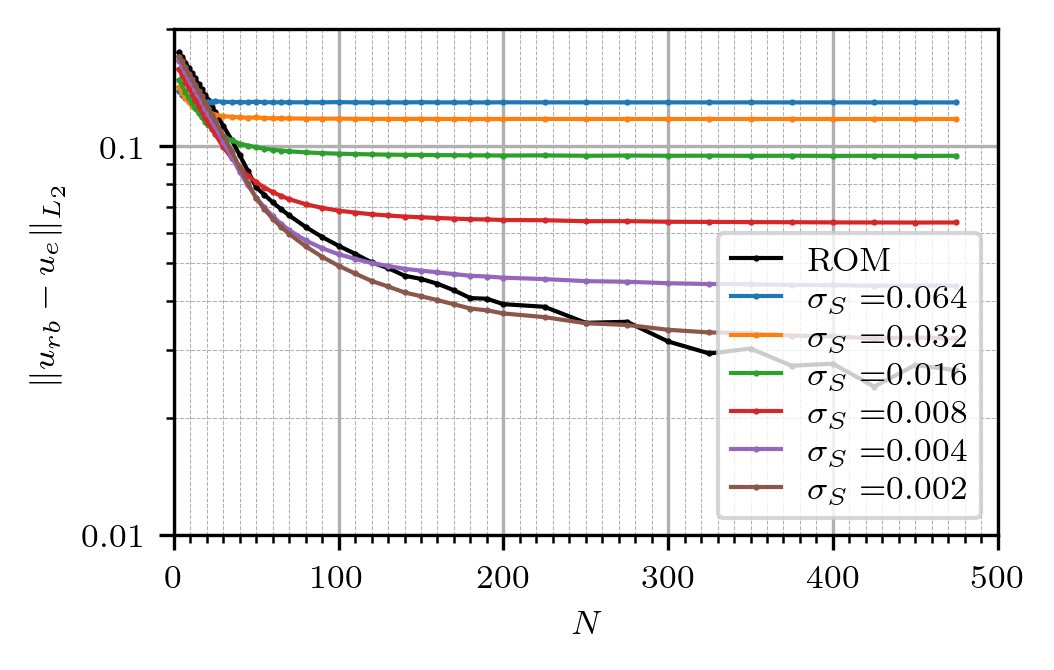

C:\Users\florianma\AppData\Local\Temp\6\ipykernel_310500\139236993.py:35: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


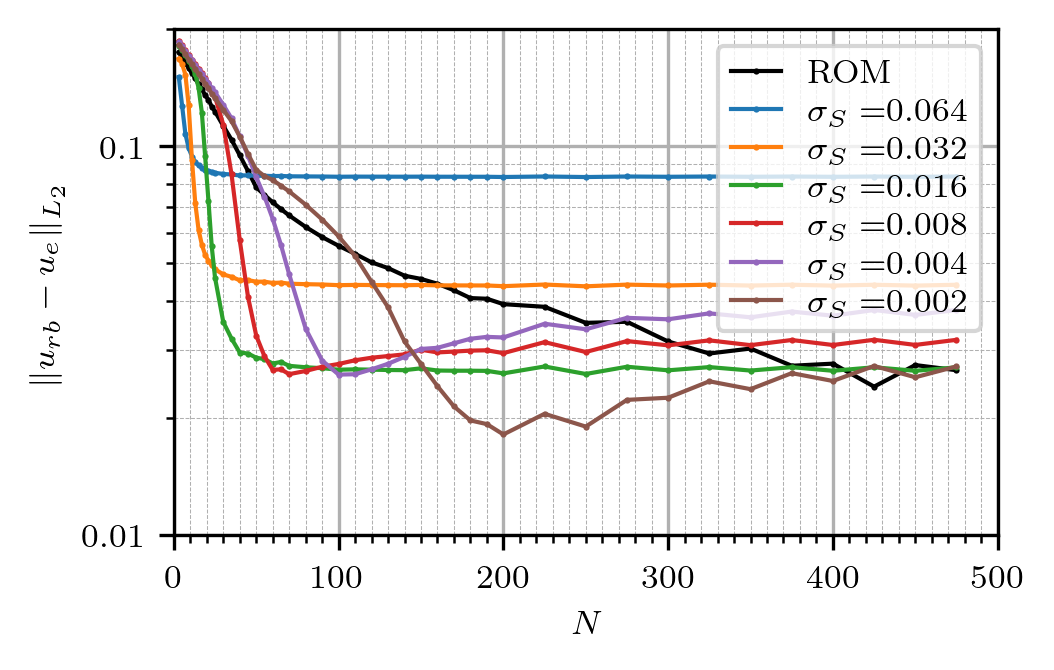

In [20]:
# N = np.arange(len(dN))
# decay_estimate = .5/N**.5


fig, ax = plt.subplots()
plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
# plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN_ROM, dN_sig_sROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
# plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_1}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.02, 0.2)
plt.ylim(0.002, 0.1)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 100, 200, 300, 400, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)
# plt.ylim(0.001, 0.05)
plt.savefig(pth+"SROM_fixed_sig.pdf", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
#plt.plot(NN_ROM, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, ideal")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN_ROM, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
# plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_1}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.07, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 100, 200, 300, 400, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)
# plt.ylim(0.0005, 0.05)
plt.savefig(pth+"DSROM_fixed_sig.pdf", bbox_inches='tight')
plt.show()

# random test data, 250 iter, w=0.1
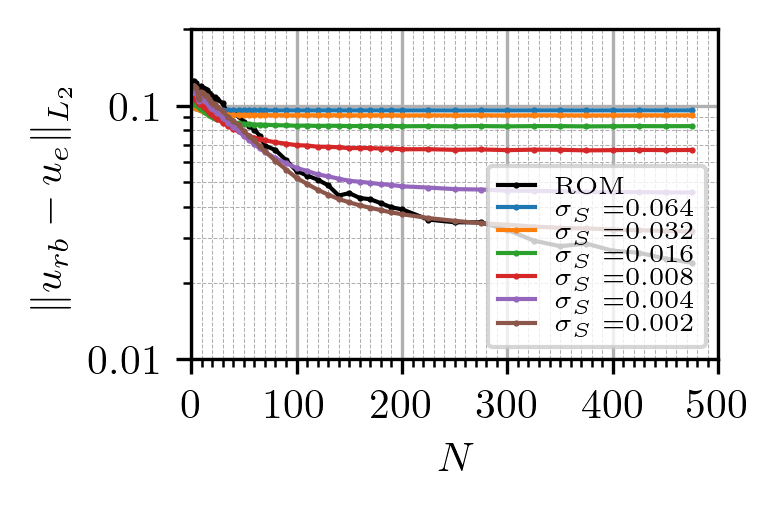

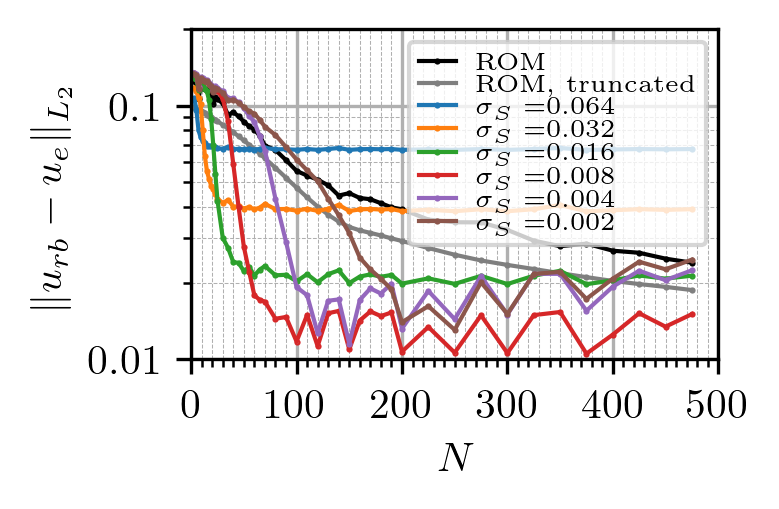

In [21]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
dN_ROM = np.zeros(len(NN))
dN_sig = np.zeros((len(NN), 10))

sig_N = np.zeros((len(NN), 10))
sig_N[:, 1] = .05/NN**.5
sig_N[:, 2] = .01/NN**.5
sig_N[:, 3] = .001/NN**.5
#sig_N[:, 3] = .4 / (NN)
sig_N[:, 4] = .3 / (NN)
sig_N[:, 5] = .2 / (NN)   # this is the one for narrow saw tooth and rectangular pulse!
sig_N[:, 6] = .1 / (NN)
sig_N[:, 7] = 10 / (NN**2)
sig_N[:, 8] = 25 / (NN**2)
sig_N[:, 9] = 40 / (NN**2)
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = True
    
    # case["mu_test"] = mu_test.copy()
    # in_range = mu_test[:, 0] < (1-1/rank)
    # case["mu_test"] = case["mu_test"][in_range, :]
    s = rank//2
    mu_test = np.linspace(s/rank, (s+1)/rank, n_test, endpoint=False)[:, None]
    case["mu_test"] = mu_test
    
    parameters = optimize_sROM(case)
    
    sig_N[i, 0] = parameters[0]
    #sig_N[i, 0] = 0.02995521

    #for sigS, dN in zip([sig_opt, sig_1, sig_2, sig_3, sig_4], [dN_sig_opt, dN_sig_1, dN_sig_2, dN_sig_3, dN_sig_4]):
    for j in range(10):
        case["sigma"] = sig_N[i, j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig[i, j] = mean_sROM
        
    dN_ROM[i] = mean_ROM
np.save(pth+"8_dN_ROM.npy", dN_ROM)
np.save(pth+"8_dN_sig.npy", dN_sig)
np.save(pth+"8_sig_N.npy", sig_N)
np.save(pth+"8_NN.npy", NN)

3
max: 0.06666666666666667
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.03333833, -, 0.17435411, 0.14138960, -, -18.9066
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.05555722, -, 0.17435411, 0.13890614, -, -20.3310
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.01111944, -, 0.17435411, 0.15289517, -, -12.3077
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.06296352, -, 0.17435411, 0.13852633, -, -20.5489
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.04815093, -, 0.17435411, 0.13944520, -, -20.0218
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.04074463, -, 0.17435411, 0.14022385, -, -19.5753
num_iter, n_train, n_test, sigma_S, s

In [22]:
dN_ROM = np.load(pth+"8_dN_ROM.npy")
dN_sig = np.load(pth+"8_dN_sig.npy")
sig_N = np.load(pth+"8_sig_N.npy")
NN = np.load(pth+"8_NN.npy")

[0.03 0.04 0.05 0.06 0.07 0.08 0.09]
[0.1]
[Text(0, 0.03, '0.03'), Text(0, 0.04, ' '), Text(0, 0.05, '0.05'), Text(0, 0.06, ' '), Text(0, 0.07, '0.07'), Text(0, 0.08, ' '), Text(0, 0.09, ' ')]


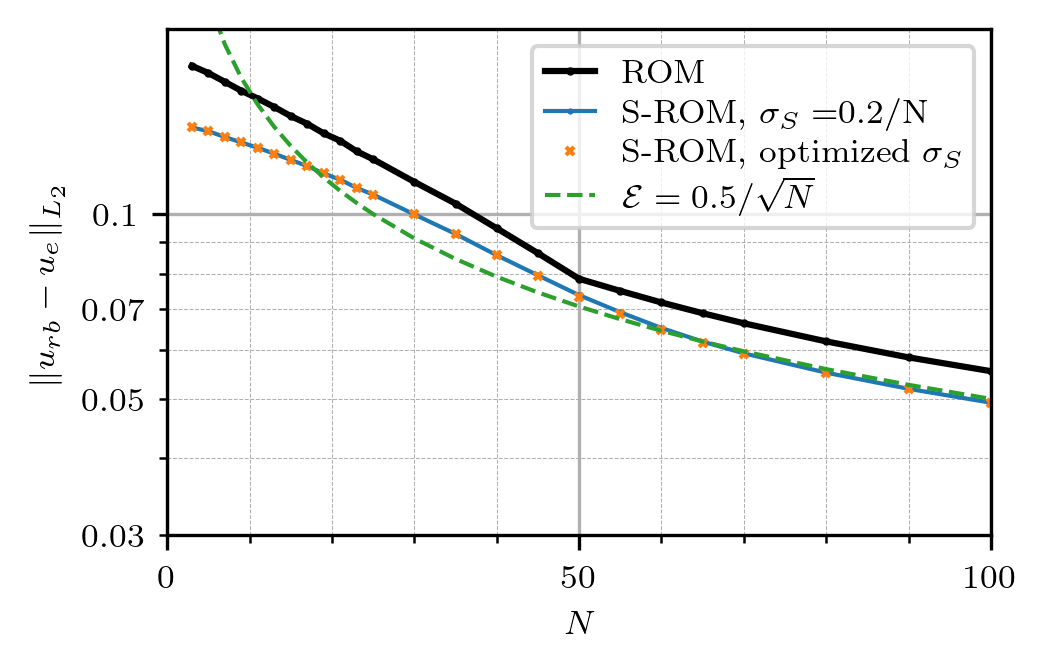

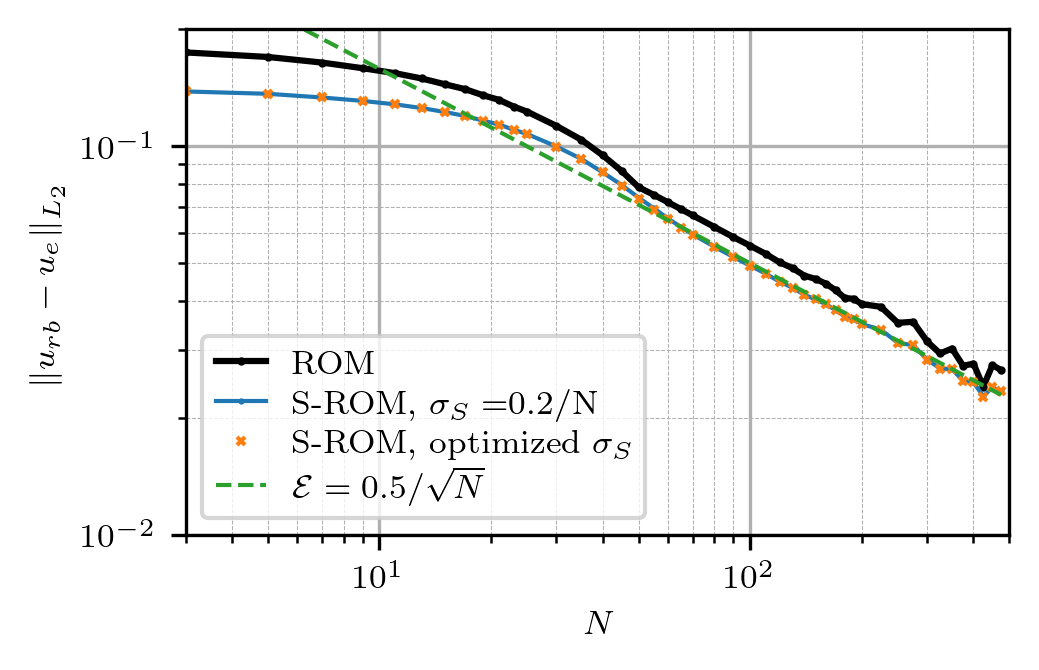

In [23]:
fig, ax = plt.subplots()
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"ROM")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"S-ROM, $\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, np.exp(-NN/300)/12, "C3--", lw=1, ms=1, label=r"$exp(-N)$")
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"S-ROM, optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")  # saw tooth w=1/45
plt.plot(NN, .5/NN**.5, "C2--", lw=1, ms=1, label=r"$\mathcal{E}=0.5/\sqrt{N}$")  # rect pulse w=0.2

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()


ax.set_yscale("log")
plt.xlim(0, 100)
plt.ylim(0.03, 0.2)


ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
ax.set_xticks([0, 50, 100], minor=False)

ax.set_yticks(np.linspace(0.03, 0.1, 8, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
# ax.set_yticks([0.03, 0.05, 0.06, 0.1], minor=False)
#ax.set_yticklabels(["0.03", "0.04", "0.06", "0.1"], minor=True)
ax.set_yticklabels(["0.1"], minor=False)




#ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
#ax.set_yticklabels(["0.01", "0.1" ], minor=False)
#ax.set_yticklabels(["0.01", "0.02", "0.03"," 0.04", "0.05", "0.06", "0.07", "0.08", "0.09", "0.1" ], minor=True)
print(ax.get_yticks(minor=True))
print(ax.get_yticks(minor=False))
print(ax.get_yticklabels(minor=True))

# fmt = lambda x, pos: '{:.2f}'.format(x, pos)
# ax.yaxis.set_minor_formatter(mpl.ticker.FuncFormatter(fmt))
# ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(fmt))
plt.savefig(pth+"SROM_sig_is_fun_of_N_preasympt.pdf", bbox_inches='tight')
plt.show()






fig, ax = plt.subplots()
plt.plot(NN, dN_ROM, "k.-", ms=2, label="ROM")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
#plt.plot(NN, dN_sig[:, 2], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[2])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"S-ROM, $\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, dN_sig[:, 7], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[7])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"S-ROM, optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .5/NN**.5, "C2--", lw=1, ms=1, label=r"$\mathcal{E}=0.5/\sqrt{N}$")# r"$u_{\mu,Srb}$"

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 500)
plt.ylim(1e-2, 0.2)
plt.savefig(pth+"SROM_sig_is_fun_of_N_asympt.pdf", bbox_inches='tight')
plt.show()

Text(0, 0.5, '$\\sigma_S$')

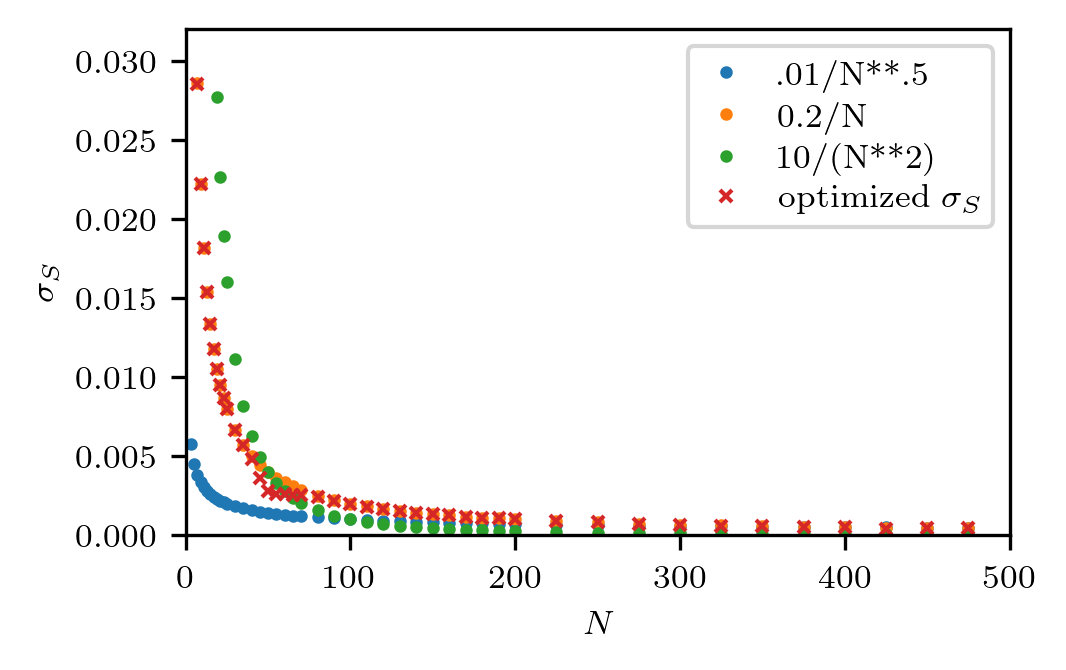

In [24]:
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, sig_N[:, i], "o", ms=2, label=lbls[i])
plt.plot(NN, sig_N[:, 0], "x", ms=3, label=r"optimized $\sigma_S$")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 0.032)
plt.xlabel("$N$")
plt.ylabel(r"$\sigma_S$")